# Introducing images



# Medical Imaging — From Pixels to Algorithms  
*An introductory lecture in medical image analysis*

---

##  What Is an Image?

At its core, an image is **a structured collection of numbers** where:

- each number corresponds to a **measurement**,  
- the organization of numbers reflects **space**,  
- and the structure often contains **meaningful patterns**.

In everyday life, we think of pictures (photos). In science, an image is:

> **A grid of values representing measurements in space.**
##  The Matrix Representation

To a computer, an image is not a "picture"; it is a mathematical array. A digital image of size  is essentially a matrix of numbers where  represents the row and  represents the column.

We can define the image function  as:
$$
f(x, y) = \begin{bmatrix}
f(0,0) & f(0,1) & \cdots & f(0, N-1) \\
f(1,0) & f(1,1) & \cdots & f(1, N-1) \\
\vdots & \vdots & \ddots & \vdots \\
f(M-1, 0) & f(M-1, 1) & \cdots & f(M-1, N-1)
\end{bmatrix}
$$
In this matrix, the entry  represents the pixel value at the top-left corner of the image.


In Python, images are just multidimensional arrays — for example using NumPy.


(64, 64)


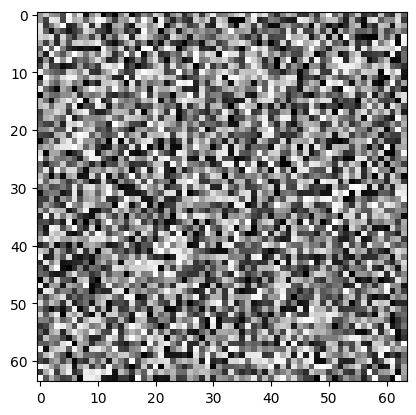

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

image = np.random.rand(64, 64)
print(image.shape)  # Output: (64, 64)
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()



# The Pixel: The Building Block of Digital Images

## 1. What is a Pixel?

The term **pixel** is a portmanteau of "Picture Element." It is the smallest addressable element in a raster image (an image formed by a grid of dots).

You can visualize a digital image as a mosaic or a tile floor. When you view the image from a distance, the tiles blend together to form smooth shapes and gradients. However, if you zoom in far enough on any digital photo, you will eventually stop seeing smooth curves and start seeing a rigid grid of colored squares.

**Each of these individual squares is a pixel.**

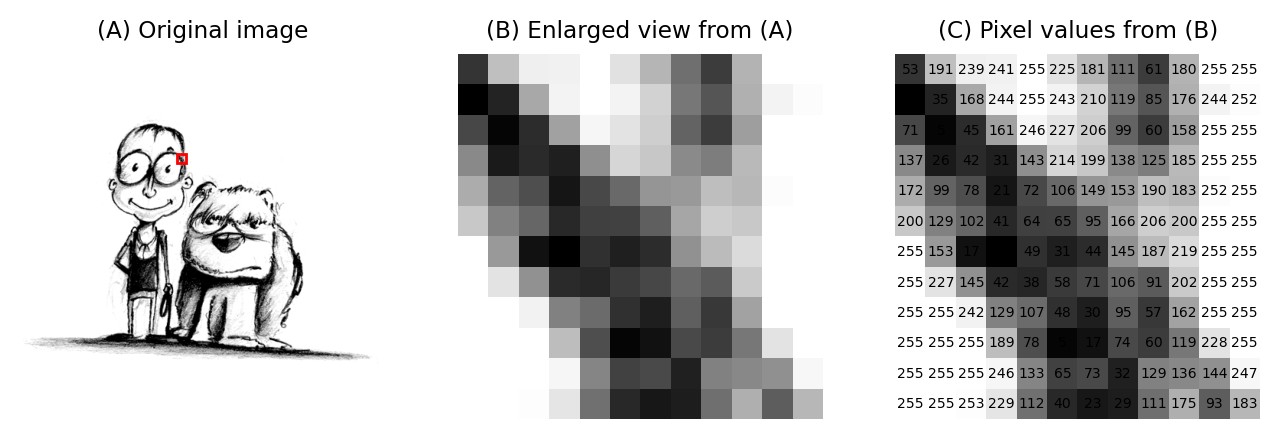
Taken from https://bioimagebook.github.io/chapters/1-concepts/1-images_and_pixels/images_and_pixels.html
## 2. How a Pixel Works

Every pixel in a digital image is defined by two primary characteristics:

* **Location:** Each pixel exists at a specific discrete coordinate  within the image grid.
* **Value:** Each pixel holds a numerical value. This number tells the computer what color or light intensity to display at that specific location.



## 4. Bit Depth and Color

So far, we’ve said that each pixel stores a **number**.  
But *how many different numbers* can a pixel store?

This is controlled by the **bit depth** = how many bits of memory are used for **one pixel**.

- With more bits → you can represent **more possible values** → **smoother** intensity or color changes.
- With fewer bits → you have **fewer possible values** → the image looks more **blocky** or **posterized**.

Mathematically:

> **Number of possible values per pixel** = \(2^{\text{bit depth}}\)

---

### 🔲 Binary Image (1‑bit)

- Uses **1 bit** per pixel → \(2^1 = 2\) possible values.
- A pixel value can only be:
  - **0** → Black  
  - **1** → White  
- Think of it as a **yes/no** or **on/off** image.

*Typical uses in imaging:*

- Document / text scanning (black text on white background)
- **Segmentation masks** (e.g. 0 = background, 1 = organ)

Visually, a binary image looks like a **sharp black‑and‑white stencil** with no gray in between.

---

### 🌫️ Grayscale Image (8‑bit)

- Uses **8 bits** per pixel → \(2^8 = 256\) possible values.
- Pixel values range from:
  - **0** → pure black  
  - **255** → pure white  
  - values in between (e.g. 128) → different shades of gray

You can think of this as a **gray “slider”** with 256 discrete positions between black and white.

*Typical uses:*

- Medical **X‑rays**
- Standard black‑and‑white photography
- Many MRI, CT, and ultrasound images are stored as **grayscale** (sometimes with >8 bits for more subtle contrast)

This higher bit depth allows us to see **fine differences in tissue intensity**, which is crucial in medical imaging.


* **Color (RGB):**
* A single pixel is composed of three separate channels: **Red**, **Green**, and **Blue**.
* If each channel is 8-bit, the pixel can represent  combinations.
* This results in approximately **16.7 million** possible colors.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

# If ipywidgets is not installed, run in a terminal:
# pip install ipywidgets

def show_gray(value):
    # Left: a small patch with a single gray value
    img = np.ones((50, 50)) * (value / 255.0)

    # Right: full 0→255 gradient with a red marker
    gradient = np.tile(np.linspace(0, 1, 256), (20, 1))

    fig, axes = plt.subplots(1, 2, figsize=(7, 3))

    # Patch
    axes[0].imshow(img, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(f"Pixel value = {value}")
    axes[0].axis("off")

    # Gradient
    axes[1].imshow(gradient, cmap="gray", vmin=0, vmax=1, aspect="auto")
    axes[1].axvline(value, color="red", linewidth=2)
    axes[1].set_title("0 → 255 grayscale scale")
    axes[1].set_xticks([0, 128, 255])
    axes[1].set_xticklabels(["0 (black)", "128 (mid‑gray)", "255 (white)"])
    axes[1].set_yticks([])

    plt.tight_layout()
    plt.show()

interact(
    show_gray,
    value=IntSlider(min=0, max=255, step=1, value=0, description="Intensity"),
)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


interactive(children=(IntSlider(value=0, description='Intensity', max=255), Output()), _dom_classes=('widget-i…

<function __main__.show_gray(value)>

## 🩺 What Are Medical Images?

Medical images are **visual representations of the human body** created to support **diagnosis, monitoring, and treatment**.

Unlike everyday images, medical images are:
- **Quantitative** (pixel values have physical meaning)
- **Multi-dimensional** (2D, 3D, or even 4D over time)
- **Acquired by physics-based scanners**


---

##  Common Medical Imaging Modalities

Each modality answers a *different clinical question*:

- **X-ray** → fast, bone-focused, projection-based  
- **CT** → high-resolution anatomy, 3D volumes  
- **MRI / CMR** → soft tissue contrast, motion, function ❤️  
- **Ultrasound** → real-time, portable, operator-dependent  

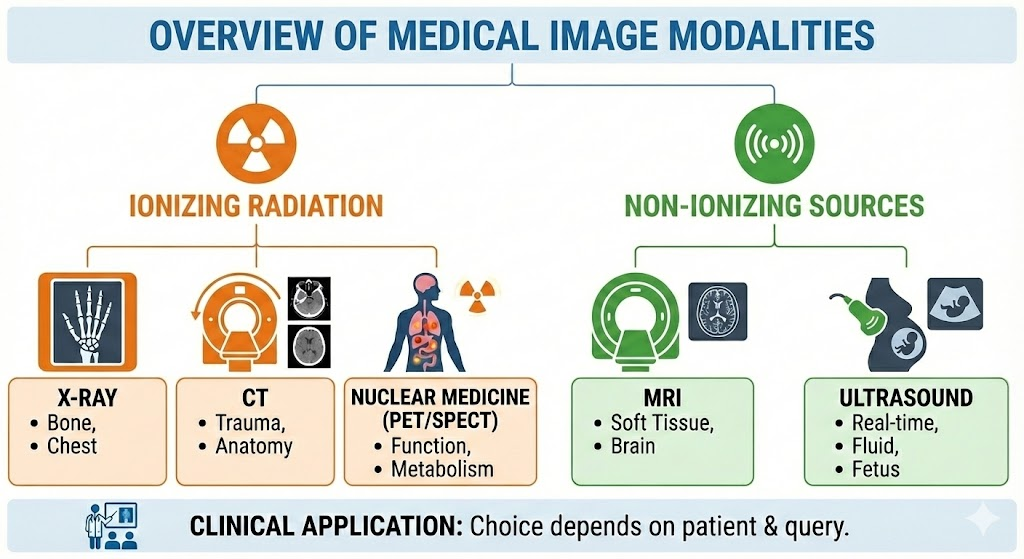
Generated with Gemini.



---

##  How Are Medical Images Different from Natural Images?

| Natural Images 📷 | Medical Images 🏥 |
|------------------|------------------|
RGB colors | Grayscale / physical intensities  
Objects anywhere | Strong anatomical structure  
Millions available | Small datasets  
Human-labeled | Expert-labeled (clinicians!)  


---

##  What Does a Pixel Mean?

In medical imaging:
- A pixel (2D) or voxel (3D) represents a **physical location**
- Intensity may represent:
  - Tissue properties (MRI)
  - X-ray attenuation (CT)
  - Acoustic reflection (ultrasound)

 Spatial resolution and voxel size matter!

---
## 🧱 From Pixels to Voxels

Medical images are often **3D**.

| Dimension | Name |
|---------|------|
2D | Pixel  
3D | **Voxel** (volume element)  

A voxel is:
- A tiny **3D box**
- With a known size (e.g. 1.5 × 1.5 × 8 mm)


---
## 🎨 Are Medical Images Color Images?


Most medical images are:
- **Single-channel (grayscale)**
- Intensity has **physical meaning**

Example:
- Bright ≠ pretty  
- Bright = *high signal / strong measurement*
---+
##  Why Do We Need Image Segmentation?

Segmentation turns images into **measurable anatomy**:

- Volumes (EDV, ESV)
- Mass and thickness
- Motion and deformation
- Inputs for **computational models**

**Segmentation = bridge between images and physiology**

---

